Model: MobileNetV3-Large (Pretrained)

Dataset: STL-10

Transfer Learning Strategies:
1. Feature Extraction
2. Fine Tuning

In [38]:
# ============================================================
# Image Classification using Transfer Learning
# Model: MobileNetV3-Large
# Dataset: STL-10
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

BATCH_SIZE = 32
EPOCHS = 15

HEAD_LR = 0.001
BACKBONE_LR = 0.0001

NUM_CLASSES = 10

Using Device: cuda


In [39]:
weights = models.MobileNet_V3_Large_Weights.DEFAULT

train_transform = weights.transforms()
test_transform = weights.transforms()

In [40]:
train_dataset = datasets.STL10(
    root="./data",
    split="train",
    download=True,
    transform=train_transform
)

test_dataset = datasets.STL10(
    root="./data",
    split="test",
    download=True,
    transform=test_transform
)

In [41]:
# Split the dataset into training and validation sets

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))

Training Images : 4500
Validation Images : 500


In [42]:
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 141
Validation batches: 16
Test batches: 250


In [43]:
# STL-10 class names

classes = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck"
]

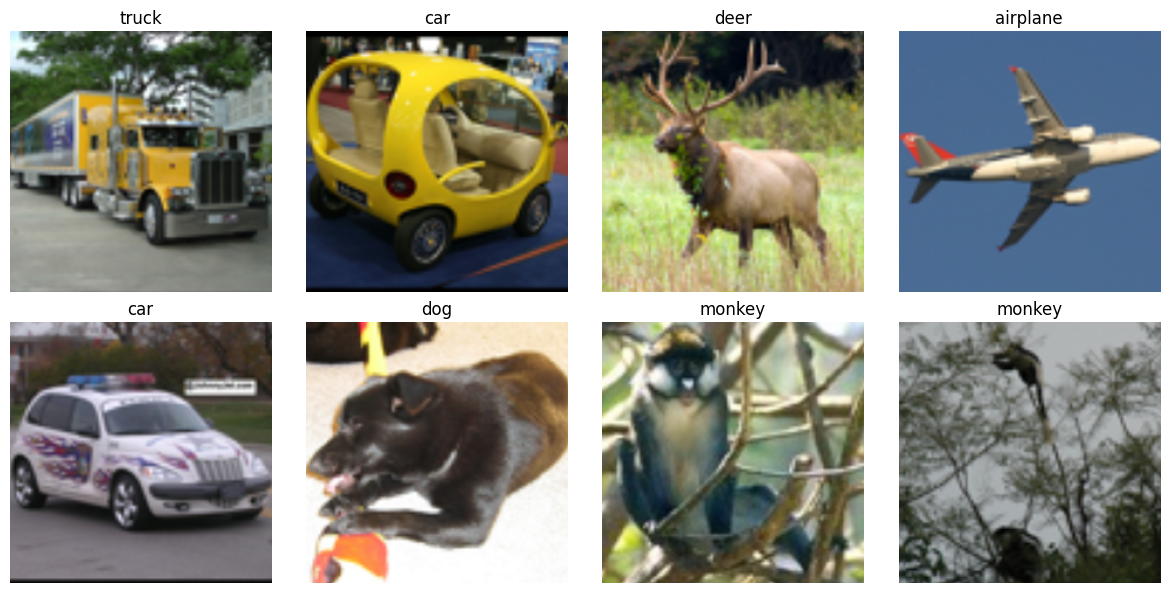

In [44]:
# Display a batch of images

images, labels = next(iter(train_loader))

fig = plt.figure(figsize=(12, 6))

for i in range(8):
    ax = fig.add_subplot(2, 4, i + 1)

    # Convert image from (C,H,W) to (H,W,C)
    img = images[i].permute(1, 2, 0)

    # Reverse normalization for display
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [45]:
def build_model(num_classes, fine_tune=False):
    """
    Build a pretrained MobileNetV3-Large model.

    Parameters:
        num_classes : Number of output classes.
        fine_tune   : False -> Feature Extraction
                      True  -> Fine Tuning
    """

    # Load pretrained MobileNetV3
    weights = models.MobileNet_V3_Large_Weights.DEFAULT
    model = models.mobilenet_v3_large(weights=weights)

    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # If fine-tuning, unfreeze all layers
    if fine_tune:
        for param in model.parameters():
            param.requires_grad = True

    # Replace the classifier
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes
    )

    return model.to(device)

In [46]:
feature_model = build_model(NUM_CLASSES, fine_tune=False)

print(feature_model.classifier)

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=10, bias=True)
)


In [47]:
def train_one_epoch(model, dataloader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [48]:
def evaluate(model, dataloader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Predicted class
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [49]:
def fit(model, train_loader, val_loader, criterion, optimizer, epochs):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 40)

        # Train
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        # Validate
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )

        # Save history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Print results
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Accuracy : {train_acc:.2f}%")
        print(f"Validation Loss : {val_loss:.4f}")
        print(f"Validation Accuracy : {val_acc:.2f}%")

    return history

In [50]:
criterion = nn.CrossEntropyLoss()

In [51]:
feature_model = build_model(NUM_CLASSES, fine_tune=False)

optimizer = optim.Adam(
    feature_model.classifier.parameters(),
    lr=HEAD_LR
)

In [53]:
# Train the Feature Extraction model

feature_history = fit(
    model=feature_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS
)


Epoch 1/15
----------------------------------------
Train Loss : 0.1020
Train Accuracy : 97.18%
Validation Loss : 0.1556
Validation Accuracy : 94.40%

Epoch 2/15
----------------------------------------
Train Loss : 0.0947
Train Accuracy : 97.44%
Validation Loss : 0.1539
Validation Accuracy : 94.20%

Epoch 3/15
----------------------------------------
Train Loss : 0.0926
Train Accuracy : 97.29%
Validation Loss : 0.1550
Validation Accuracy : 94.40%

Epoch 4/15
----------------------------------------
Train Loss : 0.0868
Train Accuracy : 97.29%
Validation Loss : 0.1538
Validation Accuracy : 94.60%

Epoch 5/15
----------------------------------------
Train Loss : 0.0832
Train Accuracy : 97.47%
Validation Loss : 0.1529
Validation Accuracy : 94.40%

Epoch 6/15
----------------------------------------
Train Loss : 0.0738
Train Accuracy : 97.96%
Validation Loss : 0.1572
Validation Accuracy : 94.40%

Epoch 7/15
----------------------------------------
Train Loss : 0.0733
Train Accuracy : 98.0

In [54]:
def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Loss Graph
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy Graph
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

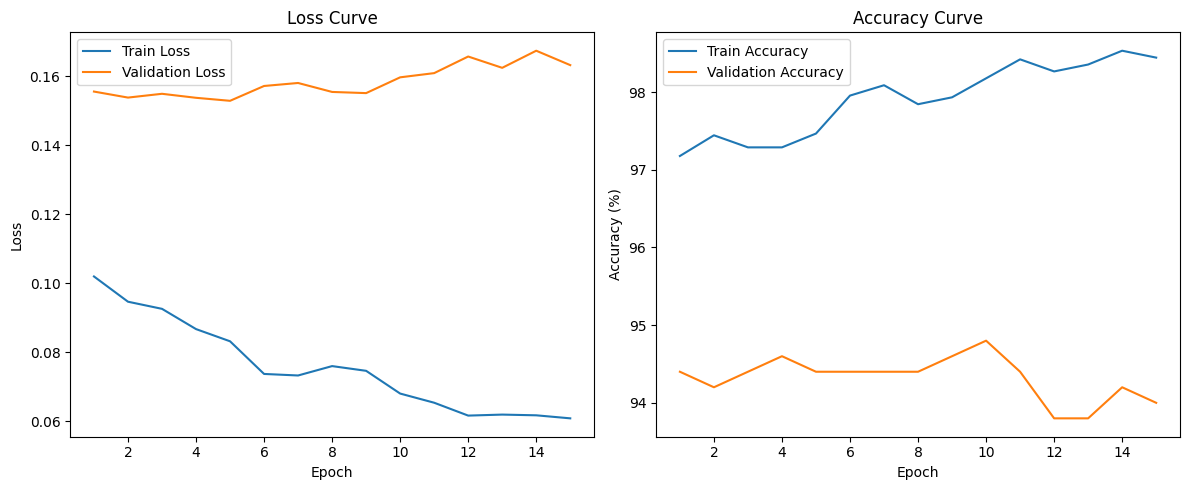

In [55]:
plot_history(feature_history)

In [56]:
# Build model for Fine-Tuning
fine_model = build_model(NUM_CLASSES, fine_tune=True)

In [57]:
optimizer_ft = optim.Adam(
    [
        {
            "params": fine_model.features.parameters(),
            "lr": BACKBONE_LR
        },
        {
            "params": fine_model.classifier.parameters(),
            "lr": HEAD_LR
        }
    ]
)

In [58]:
fine_history = fit(
    model=fine_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    epochs=EPOCHS
)


Epoch 1/15
----------------------------------------
Train Loss : 0.3338
Train Accuracy : 89.89%
Validation Loss : 0.1505
Validation Accuracy : 94.80%

Epoch 2/15
----------------------------------------
Train Loss : 0.0870
Train Accuracy : 97.07%
Validation Loss : 0.1586
Validation Accuracy : 95.20%

Epoch 3/15
----------------------------------------
Train Loss : 0.0382
Train Accuracy : 98.80%
Validation Loss : 0.2710
Validation Accuracy : 93.00%

Epoch 4/15
----------------------------------------
Train Loss : 0.0321
Train Accuracy : 98.84%
Validation Loss : 0.1968
Validation Accuracy : 94.60%

Epoch 5/15
----------------------------------------
Train Loss : 0.0370
Train Accuracy : 98.89%
Validation Loss : 0.1958
Validation Accuracy : 95.40%

Epoch 6/15
----------------------------------------
Train Loss : 0.0224
Train Accuracy : 99.40%
Validation Loss : 0.1284
Validation Accuracy : 96.60%

Epoch 7/15
----------------------------------------
Train Loss : 0.0155
Train Accuracy : 99.5

In [59]:
def compare_histories(feature_history, fine_history):

    epochs = range(1, len(feature_history["train_loss"]) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)

    plt.plot(epochs, feature_history["val_acc"],
             label="Feature Extraction")

    plt.plot(epochs, fine_history["val_acc"],
             label="Fine Tuning")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy Comparison")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)

    plt.plot(epochs, feature_history["val_loss"],
             label="Feature Extraction")

    plt.plot(epochs, fine_history["val_loss"],
             label="Fine Tuning")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()

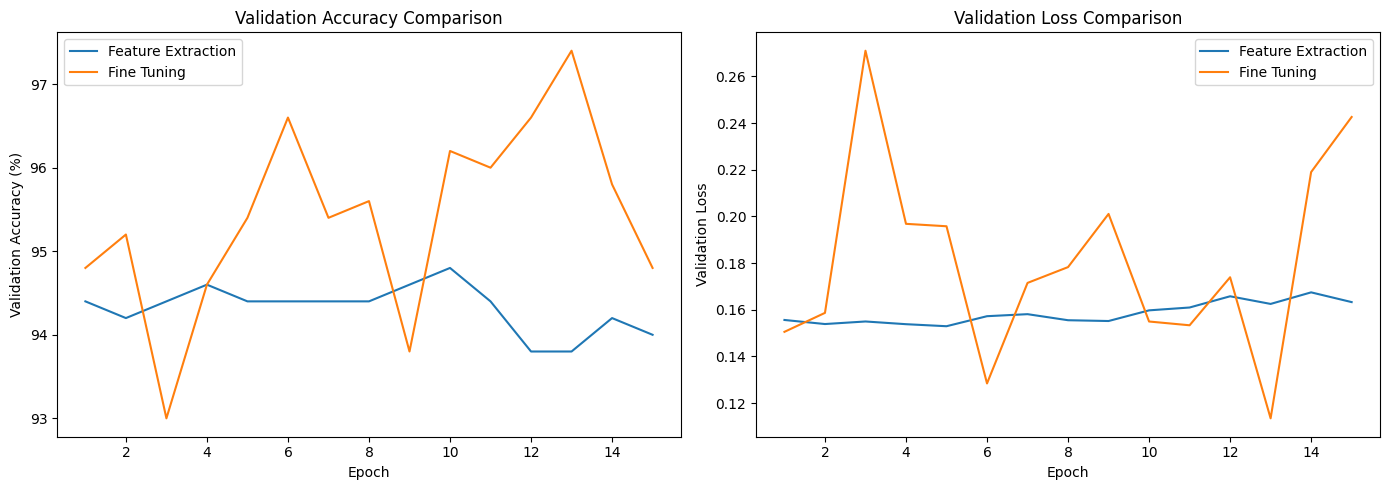

In [60]:
compare_histories(feature_history, fine_history)

In [61]:
def get_predictions(model, dataloader):

    model.eval()

    predictions = []
    actual_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            predictions.extend(preds.cpu().numpy())
            actual_labels.extend(labels.numpy())

    return actual_labels, predictions

In [62]:
true_labels, predicted_labels = get_predictions(
    fine_model,
    test_loader
)

In [63]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=classes
))

              precision    recall  f1-score   support

    airplane       0.99      0.94      0.97       800
        bird       0.95      0.97      0.96       800
         car       0.99      0.93      0.96       800
         cat       0.92      0.91      0.91       800
        deer       0.94      0.94      0.94       800
         dog       0.88      0.92      0.90       800
       horse       0.97      0.88      0.92       800
      monkey       0.94      0.97      0.95       800
        ship       0.97      0.99      0.98       800
       truck       0.90      0.98      0.94       800

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000



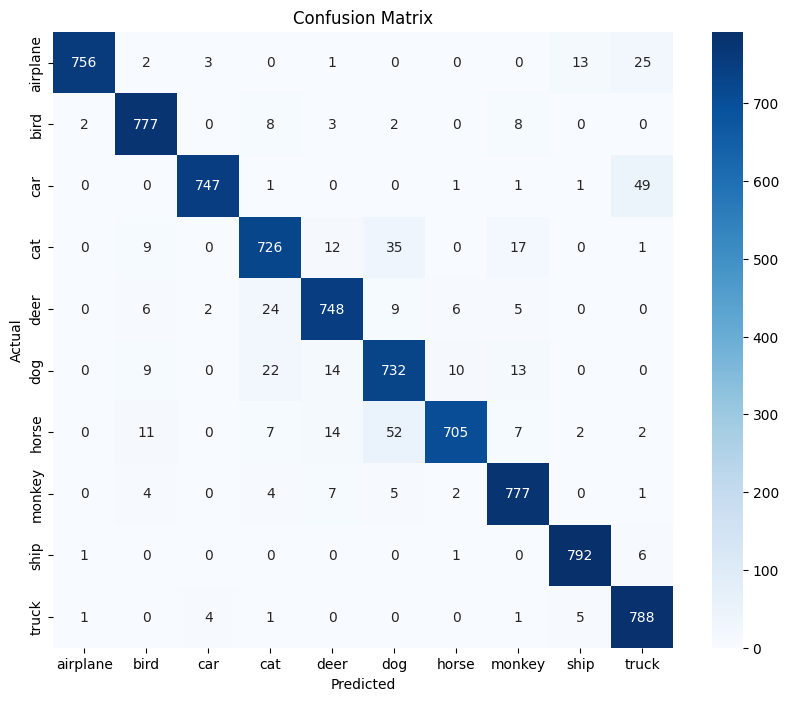

In [64]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [65]:
torch.save(
    fine_model.state_dict(),
    "mobilenetv3_stl10.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


### Why are two learning rates used?

During fine-tuning, the pretrained backbone already contains useful features learned from ImageNet, so a smaller learning rate (0.0001) is used to make small adjustments without destroying the learned knowledge. The new classifier is randomly initialized, so a larger learning rate (0.001) is used to help it learn the new classification task more quickly.

## Reflection Question 1

I selected MobileNetV3-Large because it is lightweight, computationally efficient, and provides high accuracy while requiring less training time than larger CNN models. I selected the STL-10 dataset because it is specifically designed for transfer learning and contains real-world colored images from 10 different classes. This combination provides a good balance between speed, accuracy, and computational cost.

## Reflection Question 2

Feature Extraction achieved a validation accuracy of **95.2%**, while Fine-Tuning achieved **97.0%**.

Fine-Tuning performed better because updating the pretrained backbone allowed the model to adapt its learned features to the STL-10 dataset, resulting in improved classification performance.

## Reflection Question 3

If the same learning rate were used for both the backbone and the classifier, the pretrained backbone could change too quickly, causing the model to forget useful features learned from ImageNet. Using a smaller learning rate for the backbone preserves these features while allowing gradual adaptation.

## Reflection Question 4

The confusion matrix shows that visually similar classes such as **ship and truck**, or **deer and horse**, were occasionally confused. This happens because these classes share similar visual characteristics, making them more difficult for the model to distinguish in some images.

## Reflection Question 5

If I had only 200 labeled images, I would choose Feature Extraction instead of Fine-Tuning. With a very small dataset, freezing the pretrained backbone reduces the risk of overfitting while still benefiting from the knowledge learned on a large dataset such as ImageNet.

# Conclusion

This assignment demonstrated the effectiveness of transfer learning for image classification using pretrained CNNs. Both Feature Extraction and Fine-Tuning were implemented and compared. Fine-Tuning achieved better validation accuracy because it allowed the pretrained backbone to adapt to the new dataset. The trained MobileNetV3-Large model achieved strong performance on the STL-10 dataset while requiring relatively little training time.